# StageBridge V1: GRANULAR Visual Pipeline

**Watch every step with figures!**

This notebook runs the full pipeline with visualizations at EVERY step:
- Synthetic data generation with ground truth visualization
- Stage distributions and donor structure
- Niche influence ground truth
- Training progress with loss curves (live)
- Latent space projections per epoch
- Ground truth recovery metrics

In [1]:
# ============================================================================
# CELL 1: SETUP AND CONFIGURATION
# ============================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import torch
import warnings
from IPython.display import display, clear_output
from datetime import datetime

# Path setup
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

# Configuration
DIFFICULTY = "hard"  # easy/medium/hard
N_CELLS = 2000
N_DONORS = 10
LATENT_DIM = 32
N_EPOCHS = 20
N_FOLDS = 3
BATCH_SIZE = 32
SEED = 42

# Paths
OUTPUT_DIR = Path(f"outputs/granular_{DIFFICULTY}_{datetime.now().strftime('%Y%m%d_%H%M')}")
DATA_DIR = OUTPUT_DIR / "data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("STAGEBRIDGE V1 GRANULAR PIPELINE")
print("=" * 80)
print(f"Difficulty: {DIFFICULTY.upper()}")
print(f"  - easy: Low noise, strong signals")
print(f"  - medium: Balanced")
print(f"  - hard: High noise, challenging recovery")
print(f"Cells: {N_CELLS}, Donors: {N_DONORS}")
print(f"Training: {N_EPOCHS} epochs x {N_FOLDS} folds")
print(f"Output: {OUTPUT_DIR}")
print("=" * 80)

STAGEBRIDGE V1 GRANULAR PIPELINE
Difficulty: HARD
  - easy: Low noise, strong signals
  - medium: Balanced
  - hard: High noise, challenging recovery
Cells: 2000, Donors: 10
Training: 20 epochs x 3 folds
Output: outputs/granular_hard_20260317_0036


---
## STEP 1: Generate Synthetic Data
Generate synthetic data with known ground truth for all 4 AGENTS.md suites

In [2]:
# ============================================================================
# CELL 2: GENERATE SYNTHETIC DATA
# ============================================================================
print("\n" + "="*80)
print("STEP 1: GENERATING SYNTHETIC DATA")
print("="*80)

from stagebridge.data.synthetic import generate_synthetic_v2, SyntheticConfig

print(f"\nGenerating {N_CELLS} cells with {DIFFICULTY} difficulty...")
print("This includes ground truth for:")
print("  - Suite A: Flow field dynamics (stage transitions)")
print("  - Suite B: Niche influence vectors (sender->receiver effects)")
print("  - Suite C: Clone structure (evolutionary compatibility)")
print("  - Suite D: Spatial interaction rules\n")

data_path = generate_synthetic_v2(
    output_dir=str(DATA_DIR),
    n_cells=N_CELLS,
    n_donors=N_DONORS,
    latent_dim=LATENT_DIM,
    difficulty=DIFFICULTY,
    seed=SEED,
)

print(f"\nData generated at: {data_path}")

# List generated files
print("\nGenerated files:")
for f in sorted(data_path.glob("*")):
    size = f.stat().st_size / 1024
    print(f"  {f.name}: {size:.1f} KB")


STEP 1: GENERATING SYNTHETIC DATA

Generating 2000 cells with hard difficulty...
This includes ground truth for:
  - Suite A: Flow field dynamics (stage transitions)
  - Suite B: Niche influence vectors (sender->receiver effects)
  - Suite C: Clone structure (evolutionary compatibility)
  - Suite D: Spatial interaction rules

SYNTHETIC DATA GENERATOR V2
  n_cells: 2000
  n_donors: 10
  latent_dim: 32
  difficulty: hard
  niche_influence_strength: 0.3
  seed: 42

Generated: 2000 cells, 1599 transitions
Saved to: outputs/granular_hard_20260317_0036/data

Data generated at: outputs/granular_hard_20260317_0036/data

Generated files:
  cells.parquet: 22353.1 KB
  ground_truth.json: 3.6 KB
  metadata.json: 0.4 KB
  neighborhoods.parquet: 4375.2 KB
  split_manifest.json: 1.7 KB
  stage_edges.parquet: 5.0 KB
  transitions.parquet: 1037.3 KB


In [3]:
# ============================================================================
# CELL 3: LOAD AND INSPECT DATA
# ============================================================================
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load all tables
cells_df = pd.read_parquet(data_path / "cells.parquet")
neighborhoods_df = pd.read_parquet(data_path / "neighborhoods.parquet")
transitions_df = pd.read_parquet(data_path / "transitions.parquet")
stage_edges_df = pd.read_parquet(data_path / "stage_edges.parquet")

with open(data_path / "ground_truth.json") as f:
    ground_truth = json.load(f)

with open(data_path / "split_manifest.json") as f:
    splits = json.load(f)

print(f"\nCells: {len(cells_df):,}")
print(f"Neighborhoods: {len(neighborhoods_df):,}")
print(f"Transitions: {len(transitions_df):,}")
print(f"Stage edges: {len(stage_edges_df)}")
print(f"\nDonors: {cells_df['donor_id'].nunique()}")
print(f"Stages: {cells_df['stage'].nunique()}")
print(f"Cell types: {cells_df['cell_type'].nunique()}")
print(f"Clones: {cells_df['clone_id'].nunique()}")

print("\nGround truth keys:")
for key in ground_truth.keys():
    print(f"  - {key}")


LOADING DATA

Cells: 2,000
Neighborhoods: 2,000
Transitions: 1,599
Stage edges: 3

Donors: 10
Stages: 4
Cell types: 8
Clones: 30

Ground truth keys:
  - influence_vectors
  - influential_celltypes
  - luca_rotation
  - luca_shift
  - stage_centroids
  - drift_strength
  - diffusion_strength
  - config


---
## STEP 2: Visualize Data Distribution


FIGURE: Stage Distribution


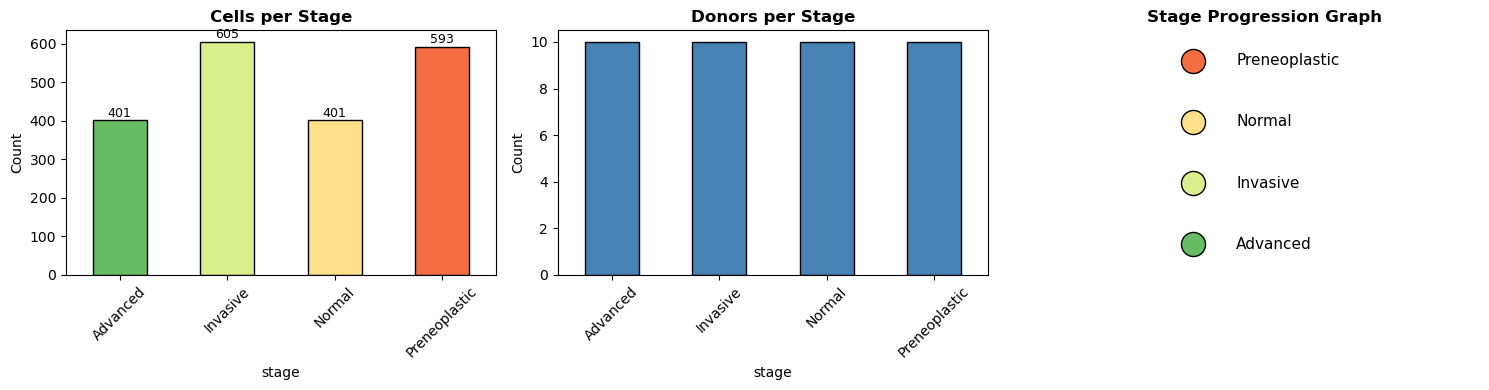

In [4]:
# ============================================================================
# CELL 4: FIGURE - STAGE DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Stage Distribution")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Stage counts
stage_counts = cells_df['stage'].value_counts().sort_index()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(stage_counts)))
stage_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title("Cells per Stage", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(stage_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

# Donors per stage
donors_per_stage = cells_df.groupby('stage')['donor_id'].nunique().sort_index()
donors_per_stage.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Donors per Stage", fontweight='bold', fontsize=12)
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# Stage graph (progression)
stages = ground_truth.get('stages', list(stage_counts.index))
stage_edges = ground_truth.get('stage_edges', [])

# Draw stage progression
ax = axes[2]
y_pos = {stage: i for i, stage in enumerate(stages)}
for stage in stages:
    ax.scatter([0], [y_pos[stage]], s=300, c=[colors[y_pos[stage]]], edgecolor='black', zorder=3)
    ax.text(0.15, y_pos[stage], stage, va='center', fontsize=11)

for src, tgt in stage_edges:
    if src in y_pos and tgt in y_pos:
        ax.annotate('', xy=(0, y_pos[tgt]), xytext=(0, y_pos[src]),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_xlim(-0.5, 1)
ax.set_ylim(-0.5, len(stages) - 0.5)
ax.set_title("Stage Progression Graph", fontweight='bold', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_stage_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


FIGURE: Donor and Clone Structure


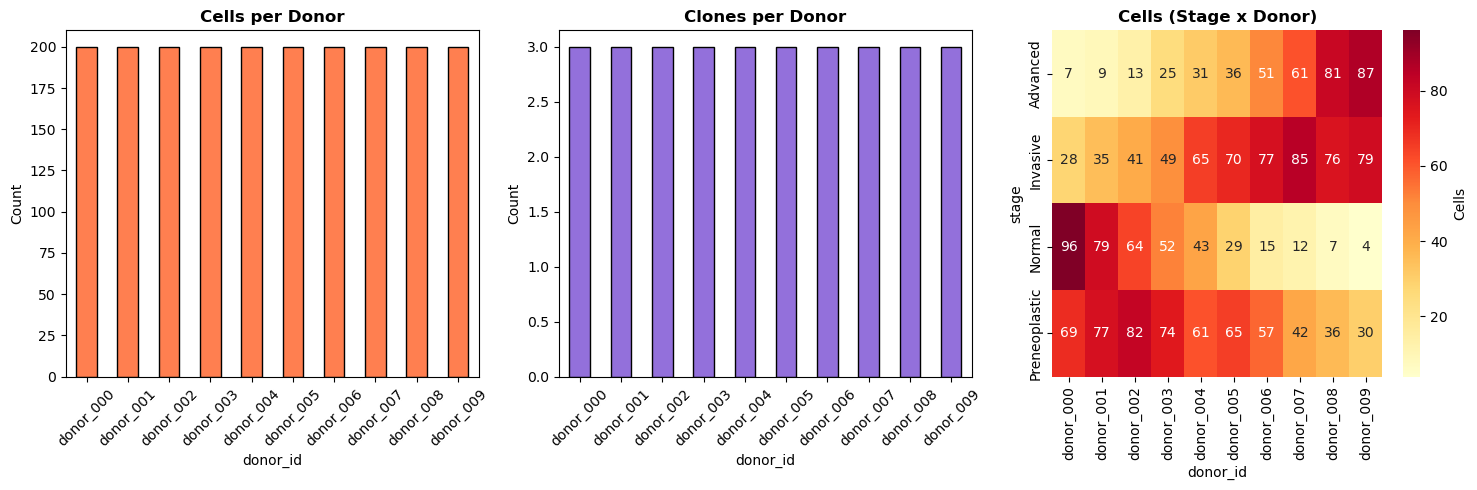

In [5]:
# ============================================================================
# CELL 5: FIGURE - DONOR STRUCTURE
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Donor and Clone Structure")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cells per donor
donor_counts = cells_df['donor_id'].value_counts().sort_index()
donor_counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title("Cells per Donor", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Clones per donor
clones_per_donor = cells_df.groupby('donor_id')['clone_id'].nunique().sort_index()
clones_per_donor.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title("Clones per Donor", fontweight='bold', fontsize=12)
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# Heatmap: Stage x Donor
stage_donor = cells_df.groupby(['stage', 'donor_id']).size().unstack(fill_value=0)
sns.heatmap(stage_donor, ax=axes[2], cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Cells'})
axes[2].set_title("Cells (Stage x Donor)", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_donor_structure.png", dpi=150, bbox_inches='tight')
plt.show()


FIGURE: Cell Type Distribution


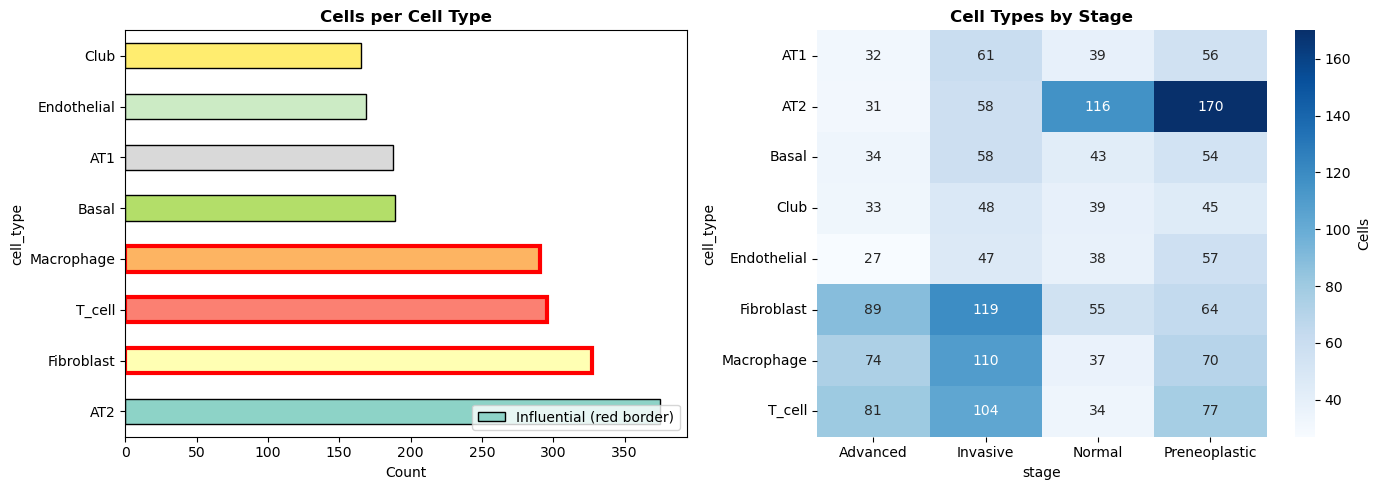


Influential cell types (ground truth): ['Fibroblast', 'Macrophage', 'T_cell']


In [6]:
# ============================================================================
# CELL 6: FIGURE - CELL TYPE DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Cell Type Distribution")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cell type counts
ct_counts = cells_df['cell_type'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(ct_counts)))
ct_counts.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title("Cells per Cell Type", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Count")

# Highlight influential cell types
influential = ground_truth.get('influential_celltypes', [])
for i, ct in enumerate(ct_counts.index):
    if ct in influential:
        axes[0].get_children()[i].set_edgecolor('red')
        axes[0].get_children()[i].set_linewidth(3)

axes[0].legend(['Influential (red border)'], loc='lower right')

# Cell type by stage heatmap
ct_stage = cells_df.groupby(['cell_type', 'stage']).size().unstack(fill_value=0)
sns.heatmap(ct_stage, ax=axes[1], cmap='Blues', annot=True, fmt='d', cbar_kws={'label': 'Cells'})
axes[1].set_title("Cell Types by Stage", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_celltype_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nInfluential cell types (ground truth): {influential}")

---
## STEP 3: Visualize Ground Truth


FIGURE: Ground Truth - Stage Centroids (Suite A: Flow Field)


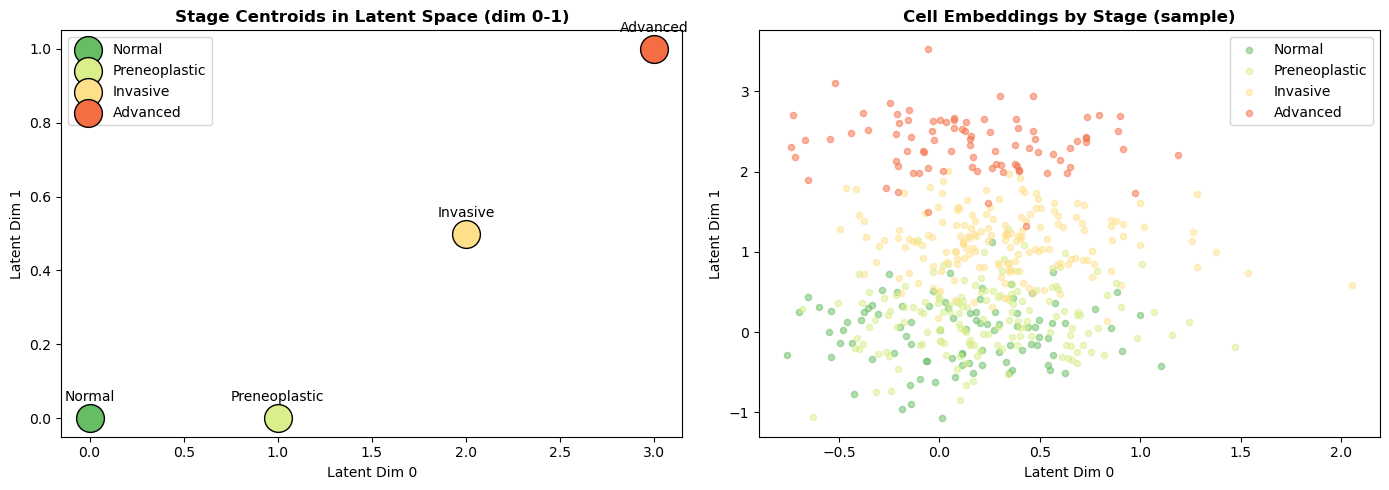

In [7]:
# ============================================================================
# CELL 7: FIGURE - GROUND TRUTH: STAGE CENTROIDS (Suite A)
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Ground Truth - Stage Centroids (Suite A: Flow Field)")
print("="*80)

# Get stage centroids from ground truth
stage_centroids = ground_truth.get('stage_centroids', {})

if stage_centroids:
    # Extract first 2 dimensions for visualization
    centroids_2d = {stage: np.array(vec)[:2] for stage, vec in stage_centroids.items()}
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot centroids
    ax = axes[0]
    stages_list = list(centroids_2d.keys())
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(stages_list)))
    
    for i, (stage, pos) in enumerate(centroids_2d.items()):
        ax.scatter(pos[0], pos[1], s=400, c=[colors[i]], edgecolor='black', zorder=3, label=stage)
        ax.annotate(stage, (pos[0], pos[1]), fontsize=10, ha='center', va='bottom', 
                   xytext=(0, 10), textcoords='offset points')
    
    # Draw edges
    for src, tgt in stage_edges:
        if src in centroids_2d and tgt in centroids_2d:
            p1, p2 = centroids_2d[src], centroids_2d[tgt]
            ax.annotate('', xy=p2, xytext=p1,
                       arrowprops=dict(arrowstyle='->', color='gray', lw=2, alpha=0.7))
    
    ax.set_title("Stage Centroids in Latent Space (dim 0-1)", fontweight='bold', fontsize=12)
    ax.set_xlabel("Latent Dim 0")
    ax.set_ylabel("Latent Dim 1")
    ax.legend(loc='best')
    
    # Plot all cells colored by stage (sample)
    ax = axes[1]
    sample_cells = cells_df.sample(min(500, len(cells_df)), random_state=42)
    
    for i, stage in enumerate(stages_list):
        mask = sample_cells['stage'] == stage
        z_fused = np.stack(sample_cells.loc[mask, 'z_fused'].values)
        ax.scatter(z_fused[:, 0], z_fused[:, 1], s=20, c=[colors[i]], alpha=0.5, label=stage)
    
    ax.set_title("Cell Embeddings by Stage (sample)", fontweight='bold', fontsize=12)
    ax.set_xlabel("Latent Dim 0")
    ax.set_ylabel("Latent Dim 1")
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig4_stage_centroids.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No stage centroids in ground truth")


FIGURE: Ground Truth - Niche Influence Vectors (Suite B)


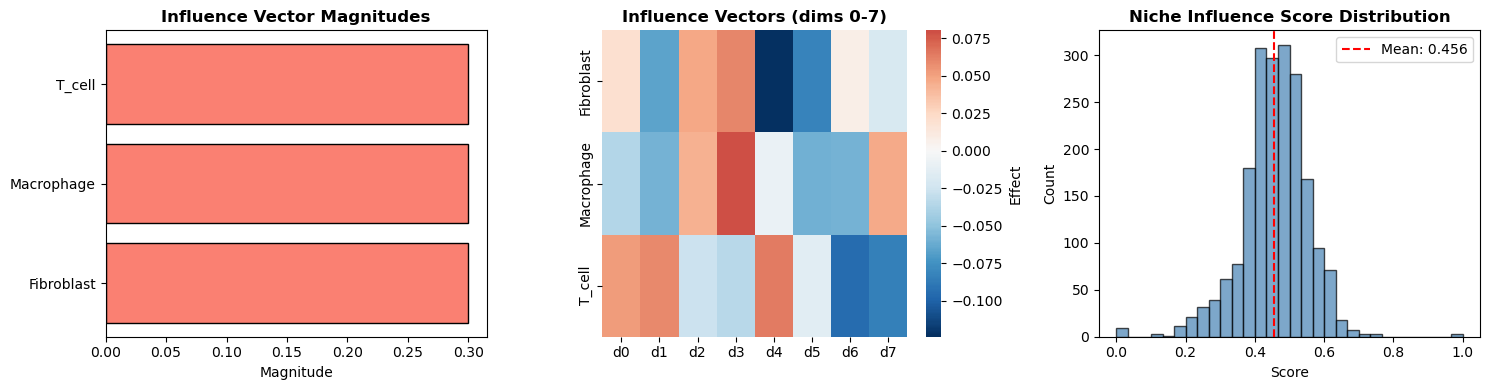


Influential cell types: ['Fibroblast', 'Macrophage', 'T_cell']
Influence magnitudes: {'Fibroblast': np.float64(0.30000000000000004), 'Macrophage': np.float64(0.30000000000000004), 'T_cell': np.float64(0.3)}


In [8]:
# ============================================================================
# CELL 8: FIGURE - GROUND TRUTH: NICHE INFLUENCE (Suite B)
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Ground Truth - Niche Influence Vectors (Suite B)")
print("="*80)

influence_vectors = ground_truth.get('influence_vectors', {})
influential_cts = ground_truth.get('influential_celltypes', [])

if influence_vectors:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Panel 1: Influence vector magnitudes
    ax = axes[0]
    magnitudes = {ct: np.linalg.norm(vec) for ct, vec in influence_vectors.items()}
    cts = list(magnitudes.keys())
    mags = list(magnitudes.values())
    bars = ax.barh(cts, mags, color='salmon', edgecolor='black')
    ax.set_title("Influence Vector Magnitudes", fontweight='bold', fontsize=12)
    ax.set_xlabel("Magnitude")
    
    # Panel 2: Influence vectors heatmap (first 8 dims)
    ax = axes[1]
    vec_matrix = np.array([influence_vectors[ct][:8] for ct in cts])
    sns.heatmap(vec_matrix, ax=ax, cmap='RdBu_r', center=0, 
                yticklabels=cts, xticklabels=[f'd{i}' for i in range(8)],
                cbar_kws={'label': 'Effect'})
    ax.set_title("Influence Vectors (dims 0-7)", fontweight='bold', fontsize=12)
    
    # Panel 3: Niche influence scores distribution
    ax = axes[2]
    ax.hist(cells_df['niche_influence_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(cells_df['niche_influence_score'].mean(), color='red', linestyle='--', 
               label=f"Mean: {cells_df['niche_influence_score'].mean():.3f}")
    ax.set_title("Niche Influence Score Distribution", fontweight='bold', fontsize=12)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig5_niche_influence_gt.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nInfluential cell types: {influential_cts}")
    print(f"Influence magnitudes: {magnitudes}")
else:
    print("No influence vectors in ground truth")


FIGURE: Ground Truth - Transition Dynamics


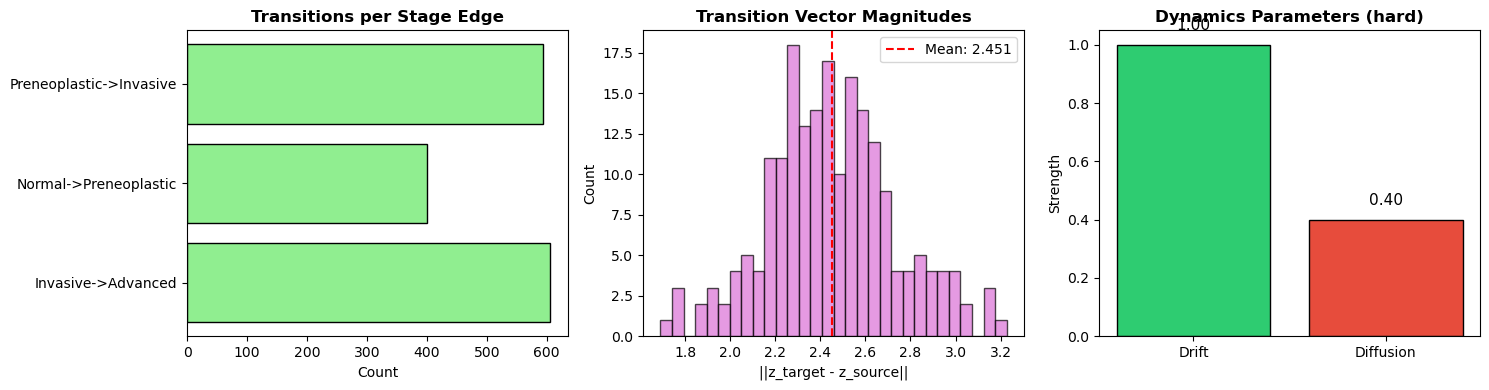


Drift strength: 1.0
Diffusion strength: 0.4
Total transitions: 1599


In [9]:
# ============================================================================
# CELL 9: FIGURE - GROUND TRUTH: TRANSITIONS (Suite A)
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Ground Truth - Transition Dynamics")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Transitions per edge
ax = axes[0]
edge_counts = transitions_df.groupby(['source_stage', 'target_stage']).size()
edge_labels = [f"{s}->{t}" for s, t in edge_counts.index]
ax.barh(edge_labels, edge_counts.values, color='lightgreen', edgecolor='black')
ax.set_title("Transitions per Stage Edge", fontweight='bold', fontsize=12)
ax.set_xlabel("Count")

# Panel 2: Transition vector magnitudes
ax = axes[1]
sample_trans = transitions_df.sample(min(200, len(transitions_df)), random_state=42)
z_src = np.stack(sample_trans['z_source'].values)
z_tgt = np.stack(sample_trans['z_target'].values)
trans_mags = np.linalg.norm(z_tgt - z_src, axis=1)
ax.hist(trans_mags, bins=30, color='orchid', edgecolor='black', alpha=0.7)
ax.axvline(trans_mags.mean(), color='red', linestyle='--', label=f"Mean: {trans_mags.mean():.3f}")
ax.set_title("Transition Vector Magnitudes", fontweight='bold', fontsize=12)
ax.set_xlabel("||z_target - z_source||")
ax.set_ylabel("Count")
ax.legend()

# Panel 3: Drift vs Diffusion visualization
ax = axes[2]
drift = ground_truth.get('drift_strength', 1.0)
diffusion = ground_truth.get('diffusion_strength', 0.2)
ax.bar(['Drift', 'Diffusion'], [drift, diffusion], color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title(f"Dynamics Parameters ({DIFFICULTY})", fontweight='bold', fontsize=12)
ax.set_ylabel("Strength")
ax.text(0, drift + 0.05, f"{drift:.2f}", ha='center', fontsize=11)
ax.text(1, diffusion + 0.05, f"{diffusion:.2f}", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig6_transitions_gt.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDrift strength: {drift}")
print(f"Diffusion strength: {diffusion}")
print(f"Total transitions: {len(transitions_df)}")


FIGURE: Spatial Structure


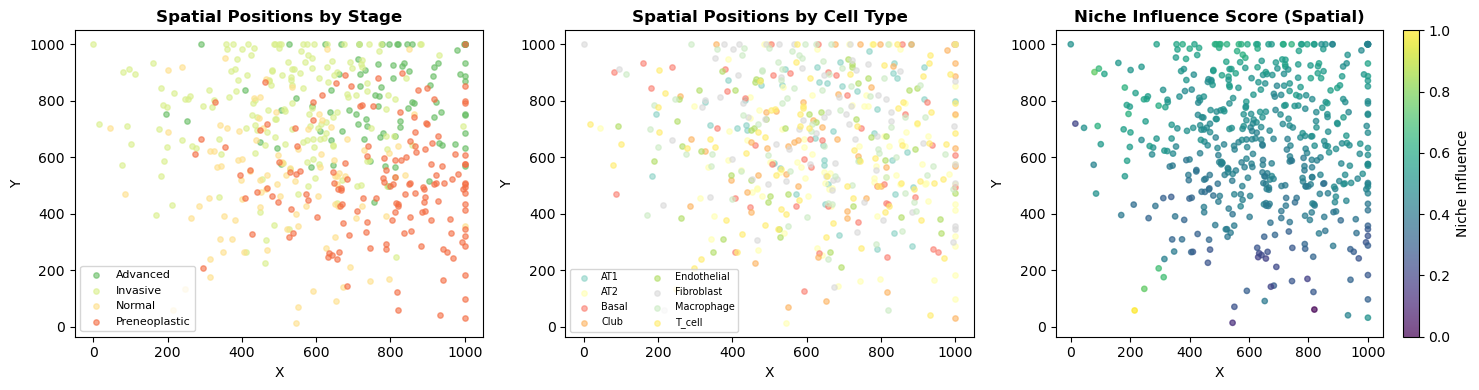

In [10]:
# ============================================================================
# CELL 10: FIGURE - SPATIAL STRUCTURE
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Spatial Structure")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sample cells for plotting
sample = cells_df.sample(min(500, len(cells_df)), random_state=42)

# Panel 1: Spatial positions colored by stage
ax = axes[0]
stages_list = sample['stage'].unique()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(stages_list)))
for i, stage in enumerate(sorted(stages_list)):
    mask = sample['stage'] == stage
    ax.scatter(sample.loc[mask, 'x_spatial'], sample.loc[mask, 'y_spatial'], 
               s=15, c=[colors[i]], alpha=0.6, label=stage)
ax.set_title("Spatial Positions by Stage", fontweight='bold', fontsize=12)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(loc='best', fontsize=8)

# Panel 2: Spatial positions colored by cell type
ax = axes[1]
ct_list = sample['cell_type'].unique()
ct_colors = plt.cm.Set3(np.linspace(0, 1, len(ct_list)))
for i, ct in enumerate(sorted(ct_list)):
    mask = sample['cell_type'] == ct
    ax.scatter(sample.loc[mask, 'x_spatial'], sample.loc[mask, 'y_spatial'], 
               s=15, c=[ct_colors[i]], alpha=0.6, label=ct)
ax.set_title("Spatial Positions by Cell Type", fontweight='bold', fontsize=12)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(loc='best', fontsize=7, ncol=2)

# Panel 3: Niche influence score spatial
ax = axes[2]
sc = ax.scatter(sample['x_spatial'], sample['y_spatial'], 
                c=sample['niche_influence_score'], s=15, cmap='viridis', alpha=0.7)
plt.colorbar(sc, ax=ax, label='Niche Influence')
ax.set_title("Niche Influence Score (Spatial)", fontweight='bold', fontsize=12)
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig7_spatial_structure.png", dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 4: Model Training

In [ ]:
# ============================================================================
# SETUP MODEL AND DATALOADERS
# ============================================================================
print("\n" + "="*80)
print("SETTING UP MODEL AND DATA")
print("="*80)

from stagebridge.data.loaders import get_dataloader
from stagebridge.pipelines.run_v1_full import StageBridgeV1Full

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# Create model
model = StageBridgeV1Full(
    latent_dim=LATENT_DIM,
    niche_encoder_type="transformer",
    use_set_encoder=True,
    use_wes=True,
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Create dataloaders for fold 0
train_loader = get_dataloader(
    data_dir=str(DATA_DIR),
    fold=0,
    split="train",
    batch_size=BATCH_SIZE,
    latent_dim=LATENT_DIM,
)

val_loader = get_dataloader(
    data_dir=str(DATA_DIR),
    fold=0,
    split="val",
    batch_size=BATCH_SIZE,
    latent_dim=LATENT_DIM,
)

test_loader = get_dataloader(
    data_dir=str(DATA_DIR),
    fold=0,
    split="test",
    batch_size=BATCH_SIZE,
    latent_dim=LATENT_DIM,
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

In [ ]:
# ============================================================================
# TRAINING WITH LIVE FLOW FIELD VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("TRAINING WITH LIVE FLOW FIELD VISUALIZATION")
print("="*80)

import torch.nn as nn
import torch.optim as optim

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = nn.MSELoss()

# History
history = {'train_loss': [], 'val_loss': [], 'lr': [], 'direction_acc': []}

# Get a fixed sample for visualization (same cells every epoch)
viz_batch = next(iter(val_loader))
viz_z_src = viz_batch.z_source[:50].to(device)
viz_z_tgt = viz_batch.z_target[:50].to(device)
viz_niche = viz_batch.niche_tokens[:50].to(device) if viz_batch.niche_tokens is not None else torch.zeros_like(viz_z_src)
viz_wes = viz_batch.wes_features[:50].to(device) if viz_batch.wes_features is not None else torch.zeros(50, 3, device=device)
viz_stages = viz_batch.source_stages[:50]

# For 2D projection - fit on ALL training data for stable projection
print("Fitting PCA for flow field visualization...")
all_train_z = []
for batch in train_loader:
    all_train_z.append(batch.z_source.numpy())
    all_train_z.append(batch.z_target.numpy())
all_train_z = np.concatenate(all_train_z)

from sklearn.decomposition import PCA
pca_viz = PCA(n_components=2, random_state=42)
pca_viz.fit(all_train_z)

# Create grid for flow field
grid_resolution = 15
x_range = np.percentile(pca_viz.transform(all_train_z)[:, 0], [5, 95])
y_range = np.percentile(pca_viz.transform(all_train_z)[:, 1], [5, 95])
xx, yy = np.meshgrid(
    np.linspace(x_range[0], x_range[1], grid_resolution),
    np.linspace(y_range[0], y_range[1], grid_resolution)
)
grid_2d = np.column_stack([xx.ravel(), yy.ravel()])

# Invert PCA to get grid points in latent space
grid_latent = pca_viz.inverse_transform(grid_2d)
grid_tensor = torch.from_numpy(grid_latent).float().to(device)

# Dummy niche/wes for grid predictions
grid_niche = torch.zeros(len(grid_latent), viz_niche.shape[1], viz_niche.shape[2], device=device) if len(viz_niche.shape) == 3 else torch.zeros(len(grid_latent), LATENT_DIM, device=device)
grid_wes = torch.zeros(len(grid_latent), 3, device=device)

best_val_loss = float('inf')
best_model_state = None

# Create figure
fig = plt.figure(figsize=(20, 10))
plt.ion()

print("Starting training with flow field visualization...")

for epoch in range(N_EPOCHS):
    # ===== TRAINING =====
    model.train()
    train_losses = []
    
    for batch in train_loader:
        z_src = batch.z_source.to(device)
        z_tgt = batch.z_target.to(device)
        niche = batch.niche_tokens.to(device) if batch.niche_tokens is not None else torch.zeros_like(z_src)
        wes = batch.wes_features.to(device) if batch.wes_features is not None else torch.zeros(z_src.size(0), 3, device=device)
        
        optimizer.zero_grad()
        z_pred = model(z_src, niche, wes)
        loss = criterion(z_pred, z_tgt)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    # ===== VALIDATION =====
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for batch in val_loader:
            z_src = batch.z_source.to(device)
            z_tgt = batch.z_target.to(device)
            niche = batch.niche_tokens.to(device) if batch.niche_tokens is not None else torch.zeros_like(z_src)
            wes = batch.wes_features.to(device) if batch.wes_features is not None else torch.zeros(z_src.size(0), 3, device=device)
            z_pred = model(z_src, niche, wes)
            val_losses.append(criterion(z_pred, z_tgt).item())
        
        # Get predictions for visualization sample
        viz_pred = model(viz_z_src, viz_niche, viz_wes).cpu().numpy()
        
        # Get flow field predictions
        grid_pred = model(grid_tensor, grid_niche, grid_wes).cpu().numpy()
    
    # Record metrics
    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(scheduler.get_last_lr()[0])
    
    # Compute direction accuracy
    viz_src_np = viz_z_src.cpu().numpy()
    viz_tgt_np = viz_z_tgt.cpu().numpy()
    true_dir = viz_tgt_np - viz_src_np
    pred_dir = viz_pred - viz_src_np
    cosines = np.sum(true_dir * pred_dir, axis=1) / (np.linalg.norm(true_dir, axis=1) * np.linalg.norm(pred_dir, axis=1) + 1e-8)
    dir_acc = (cosines > 0.5).mean()
    history['direction_acc'].append(dir_acc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    scheduler.step()
    
    # ===== LIVE VISUALIZATION =====
    clear_output(wait=True)
    fig.clear()
    
    # Create grid: 2 rows, 3 columns
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.25)
    
    # Panel 1: Loss curves
    ax1 = fig.add_subplot(gs[0, 0])
    epochs_so_far = range(1, epoch + 2)
    ax1.semilogy(epochs_so_far, history['train_loss'], 'b-o', label='Train', markersize=4)
    ax1.semilogy(epochs_so_far, history['val_loss'], 'r-s', label='Val', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (log)')
    ax1.set_title(f'Epoch {epoch+1}/{N_EPOCHS} | Best: {best_val_loss:.4f}', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Direction accuracy
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs_so_far, history['direction_acc'], 'g-^', markersize=5, linewidth=2)
    ax2.fill_between(epochs_so_far, 0, history['direction_acc'], alpha=0.3, color='green')
    ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Direction Accuracy')
    ax2.set_title(f'Flow Accuracy: {dir_acc:.1%}', fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: Prediction correlation
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(viz_tgt_np[:, 0], viz_pred[:, 0], alpha=0.6, s=30, c='steelblue')
    lims = [min(viz_tgt_np[:, 0].min(), viz_pred[:, 0].min()) - 0.5,
            max(viz_tgt_np[:, 0].max(), viz_pred[:, 0].max()) + 0.5]
    ax3.plot(lims, lims, 'r--', linewidth=2)
    ax3.set_xlabel('Target')
    ax3.set_ylabel('Predicted')
    corr = np.corrcoef(viz_tgt_np.flatten(), viz_pred.flatten())[0, 1]
    ax3.set_title(f'Correlation: r={corr:.3f}', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Panel 4: FLOW FIELD (the really cool part!)
    ax4 = fig.add_subplot(gs[1, :2])  # Span 2 columns
    
    # Compute flow vectors in 2D
    grid_pred_2d = pca_viz.transform(grid_pred)
    flow_u = grid_pred_2d[:, 0] - grid_2d[:, 0]
    flow_v = grid_pred_2d[:, 1] - grid_2d[:, 1]
    
    # Normalize for visualization
    flow_mag = np.sqrt(flow_u**2 + flow_v**2) + 1e-8
    flow_u_norm = flow_u / flow_mag
    flow_v_norm = flow_v / flow_mag
    
    # Plot cells colored by stage
    src_2d = pca_viz.transform(viz_src_np)
    stages_unique = sorted(set(viz_stages))
    stage_colors = plt.cm.Spectral(np.linspace(0, 1, len(stages_unique)))
    stage_cmap = {s: stage_colors[i] for i, s in enumerate(stages_unique)}
    
    for stage in stages_unique:
        mask = np.array(viz_stages) == stage
        ax4.scatter(src_2d[mask, 0], src_2d[mask, 1], s=80, c=[stage_cmap[stage]], 
                   edgecolor='white', linewidth=1, label=stage, zorder=5)
    
    # Draw flow field with streamplot
    U = flow_u_norm.reshape(grid_resolution, grid_resolution)
    V = flow_v_norm.reshape(grid_resolution, grid_resolution)
    speed = flow_mag.reshape(grid_resolution, grid_resolution)
    
    # Quiver plot for flow field
    ax4.quiver(xx, yy, U, V, speed, cmap='coolwarm', alpha=0.7, scale=25, width=0.004)
    
    # Add streamlines
    try:
        ax4.streamplot(xx, yy, U, V, color=speed, cmap='coolwarm', density=1.2, 
                       linewidth=1, arrowsize=1.2, alpha=0.6)
    except:
        pass  # streamplot can fail with some data
    
    ax4.set_xlabel('PC1 (Cancer Progression →)', fontsize=11)
    ax4.set_ylabel('PC2', fontsize=11)
    ax4.set_title('🌊 LEARNED FLOW FIELD: Cell State Transitions', fontweight='bold', fontsize=12)
    ax4.legend(loc='upper left', fontsize=8, title='Stage')
    ax4.set_xlim(x_range[0] - 0.5, x_range[1] + 0.5)
    ax4.set_ylim(y_range[0] - 0.5, y_range[1] + 0.5)
    
    # Panel 5: Sample transitions
    ax5 = fig.add_subplot(gs[1, 2])
    
    # Show a few individual transitions
    n_show = min(15, len(src_2d))
    tgt_2d = pca_viz.transform(viz_tgt_np)
    pred_2d = pca_viz.transform(viz_pred)
    
    for i in range(n_show):
        color = 'limegreen' if cosines[i] > 0.7 else 'orange' if cosines[i] > 0.3 else 'red'
        # True (dashed)
        ax5.plot([src_2d[i, 0], tgt_2d[i, 0]], [src_2d[i, 1], tgt_2d[i, 1]], 
                'g--', alpha=0.4, linewidth=1)
        # Predicted (solid)
        ax5.annotate('', xy=pred_2d[i], xytext=src_2d[i],
                    arrowprops=dict(arrowstyle='->', color=color, lw=2, alpha=0.8))
    
    ax5.scatter(src_2d[:n_show, 0], src_2d[:n_show, 1], s=50, c='blue', edgecolor='white', zorder=5, label='Source')
    ax5.scatter(tgt_2d[:n_show, 0], tgt_2d[:n_show, 1], s=50, c='green', marker='s', edgecolor='white', zorder=5, label='Target')
    ax5.set_xlabel('PC1')
    ax5.set_ylabel('PC2')
    ax5.set_title('Sample Transitions', fontweight='bold')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.2)
    
    fig.suptitle(f'StageBridge Training: Learning Cancer Progression Dynamics', fontsize=14, fontweight='bold', y=1.02)
    
    plt.savefig(OUTPUT_DIR / f"training_epoch_{epoch+1:02d}.png", dpi=100, bbox_inches='tight')
    display(fig)

plt.ioff()
plt.close()

print(f"\n{'='*60}")
print("TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Final direction accuracy: {history['direction_acc'][-1]:.1%}")

In [ ]:
# ============================================================================
# CELL 14: FIGURE - FINAL TRAINING CURVES
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Final Training Curves")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(1, N_EPOCHS + 1)

# Loss curves
ax = axes[0]
ax.semilogy(epochs, history['train_loss'], 'b-', label='Train', linewidth=2, marker='o', markersize=4)
ax.semilogy(epochs, history['val_loss'], 'r-', label='Val', linewidth=2, marker='s', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Training & Validation Loss', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate
ax = axes[1]
ax.plot(epochs, history['lr'], 'g-', linewidth=2, marker='^', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

# Overfitting indicator
ax = axes[2]
gap = np.array(history['val_loss']) - np.array(history['train_loss'])
colors = ['green' if g < 0.01 else 'orange' if g < 0.05 else 'red' for g in gap]
ax.bar(epochs, gap, color=colors, edgecolor='black')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val - Train Loss')
ax.set_title('Generalization Gap', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig9_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal train loss: {history['train_loss'][-1]:.6f}")
print(f"Final val loss: {history['val_loss'][-1]:.6f}")
print(f"Best val loss: {best_val_loss:.6f}")

---
## STEP 6: Evaluation and Ground Truth Recovery

In [ ]:
# ============================================================================
# EVALUATION ON TEST SET
# ============================================================================
print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)

# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Test evaluation
test_preds = []
test_targets = []
test_sources = []
test_stages = []

with torch.no_grad():
    for batch in test_loader:
        z_src = batch.z_source.to(device)
        z_tgt = batch.z_target.to(device)
        niche = batch.niche_tokens.to(device) if batch.niche_tokens is not None else torch.zeros_like(z_src)
        wes = batch.wes_features.to(device) if batch.wes_features is not None else torch.zeros(z_src.size(0), 3, device=device)
        
        z_pred = model(z_src, niche, wes)
        
        test_preds.append(z_pred.cpu().numpy())
        test_targets.append(z_tgt.cpu().numpy())
        test_sources.append(z_src.cpu().numpy())
        test_stages.extend(batch.source_stages)

test_preds = np.concatenate(test_preds)
test_targets = np.concatenate(test_targets)
test_sources = np.concatenate(test_sources)

# Compute metrics
from scipy.stats import wasserstein_distance

mse = np.mean((test_preds - test_targets) ** 2)
mae = np.mean(np.abs(test_preds - test_targets))
w_dist = np.mean([wasserstein_distance(test_preds[:, i], test_targets[:, i]) 
                  for i in range(test_preds.shape[1])])

# Prediction errors for later use
pred_errors = np.linalg.norm(test_preds - test_targets, axis=1)

print(f"\nTest Metrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  Wasserstein: {w_dist:.6f}")
print(f"  Mean L2 Error: {pred_errors.mean():.6f}")

In [ ]:
# ============================================================================
# CELL 16: FIGURE - TEST SET PREDICTIONS
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Test Set Predictions")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Panel 1: Predicted vs Target (dim 0)
ax = axes[0, 0]
ax.scatter(test_targets[:, 0], test_preds[:, 0], alpha=0.5, s=15, c='steelblue')
ax.plot([-3, 3], [-3, 3], 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('Target (dim 0)')
ax.set_ylabel('Predicted (dim 0)')
ax.set_title('Prediction vs Target (dim 0)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Predicted vs Target (dim 1)
ax = axes[0, 1]
ax.scatter(test_targets[:, 1], test_preds[:, 1], alpha=0.5, s=15, c='coral')
ax.plot([-3, 3], [-3, 3], 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('Target (dim 1)')
ax.set_ylabel('Predicted (dim 1)')
ax.set_title('Prediction vs Target (dim 1)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Error distribution
ax = axes[0, 2]
errors = np.linalg.norm(test_preds - test_targets, axis=1)
ax.hist(errors, bins=30, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {errors.mean():.3f}')
ax.set_xlabel('Prediction Error (L2)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend()

# Panel 4: Transition vectors in 2D (sample)
ax = axes[1, 0]
n_show = min(100, len(test_sources))
for i in range(n_show):
    ax.arrow(test_sources[i, 0], test_sources[i, 1],
             test_preds[i, 0] - test_sources[i, 0],
             test_preds[i, 1] - test_sources[i, 1],
             head_width=0.05, head_length=0.02, fc='blue', ec='blue', alpha=0.3)
ax.set_xlabel('Dim 0')
ax.set_ylabel('Dim 1')
ax.set_title('Predicted Transitions (sample)', fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 5: Per-dimension correlation
ax = axes[1, 1]
correlations = [np.corrcoef(test_preds[:, i], test_targets[:, i])[0, 1] 
                for i in range(min(LATENT_DIM, 16))]
ax.bar(range(len(correlations)), correlations, color='teal', edgecolor='black')
ax.axhline(0.8, color='red', linestyle='--', label='r=0.8')
ax.set_xlabel('Latent Dimension')
ax.set_ylabel('Correlation')
ax.set_title('Per-Dimension Correlation', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()

# Panel 6: Metrics summary
ax = axes[1, 2]
ax.axis('off')
metrics_text = f"""
TEST SET METRICS
{'='*30}

MSE:         {mse:.6f}
MAE:         {mae:.6f}
Wasserstein: {w_dist:.6f}

Mean Error:  {errors.mean():.6f}
Std Error:   {errors.std():.6f}

Mean Corr:   {np.mean(correlations):.4f}

Difficulty:  {DIFFICULTY.upper()}
"""
ax.text(0.1, 0.9, metrics_text, transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig10_test_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# CELL 17: FIGURE - LATENT SPACE VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Latent Space Visualization (UMAP)")
print("="*80)

try:
    from umap import UMAP
    
    # Combine source, target, predicted
    all_z = np.vstack([test_sources, test_targets, test_preds])
    labels = ['Source'] * len(test_sources) + ['Target'] * len(test_targets) + ['Predicted'] * len(test_preds)
    
    # Fit UMAP
    print("Fitting UMAP...")
    umap = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    z_2d = umap.fit_transform(all_z)
    
    n = len(test_sources)
    z_src_2d = z_2d[:n]
    z_tgt_2d = z_2d[n:2*n]
    z_pred_2d = z_2d[2*n:]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Panel 1: Source and Target
    ax = axes[0]
    ax.scatter(z_src_2d[:, 0], z_src_2d[:, 1], s=15, alpha=0.5, c='blue', label='Source')
    ax.scatter(z_tgt_2d[:, 0], z_tgt_2d[:, 1], s=15, alpha=0.5, c='green', label='Target')
    ax.set_title('Source vs Target States', fontweight='bold')
    ax.legend()
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    # Panel 2: Target and Predicted
    ax = axes[1]
    ax.scatter(z_tgt_2d[:, 0], z_tgt_2d[:, 1], s=15, alpha=0.5, c='green', label='Target')
    ax.scatter(z_pred_2d[:, 0], z_pred_2d[:, 1], s=15, alpha=0.5, c='red', label='Predicted')
    ax.set_title('Target vs Predicted States', fontweight='bold')
    ax.legend()
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    # Panel 3: All three
    ax = axes[2]
    ax.scatter(z_src_2d[:, 0], z_src_2d[:, 1], s=15, alpha=0.4, c='blue', label='Source')
    ax.scatter(z_tgt_2d[:, 0], z_tgt_2d[:, 1], s=15, alpha=0.4, c='green', label='Target')
    ax.scatter(z_pred_2d[:, 0], z_pred_2d[:, 1], s=15, alpha=0.4, c='red', label='Predicted')
    ax.set_title('All States (UMAP)', fontweight='bold')
    ax.legend()
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig11_umap_latent.png", dpi=150, bbox_inches='tight')
    plt.show()
    
except ImportError:
    print("UMAP not installed. Skipping latent visualization.")
    print("Install with: pip install umap-learn")

---
## STEP 7: Ground Truth Recovery Analysis

In [ ]:
# ============================================================================
# CELL 17: FIGURE - EMBEDDINGS (PCA, UMAP, PHATE, t-SNE)
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Latent Space Embeddings")
print("="*80)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Combine all test data
all_z = np.vstack([test_sources, test_targets, test_preds])
n = len(test_sources)
point_types = ['Source']*n + ['Target']*n + ['Predicted']*n

# Also get stage labels for coloring
# We'll use source stages for all points
test_stages = []
for batch in test_loader:
    test_stages.extend(batch['source_stage'])
test_stages = test_stages[:n]  # Match length

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# ===== ROW 1: Color by point type (Source/Target/Predicted) =====

# PCA
print("  Computing PCA...")
pca = PCA(n_components=2, random_state=42)
z_pca = pca.fit_transform(all_z)

ax = axes[0, 0]
for i, (label, color) in enumerate([('Source', 'blue'), ('Target', 'green'), ('Predicted', 'red')]):
    mask = np.array(point_types) == label
    ax.scatter(z_pca[mask, 0], z_pca[mask, 1], s=10, alpha=0.5, c=color, label=label)
ax.set_title(f'PCA (var: {pca.explained_variance_ratio_.sum():.1%})', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=8)

# t-SNE
print("  Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(all_z)

ax = axes[0, 1]
for i, (label, color) in enumerate([('Source', 'blue'), ('Target', 'green'), ('Predicted', 'red')]):
    mask = np.array(point_types) == label
    ax.scatter(z_tsne[mask, 0], z_tsne[mask, 1], s=10, alpha=0.5, c=color, label=label)
ax.set_title('t-SNE', fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=8)

# UMAP
print("  Computing UMAP...")
try:
    from umap import UMAP
    umap_model = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    z_umap = umap_model.fit_transform(all_z)
    
    ax = axes[0, 2]
    for i, (label, color) in enumerate([('Source', 'blue'), ('Target', 'green'), ('Predicted', 'red')]):
        mask = np.array(point_types) == label
        ax.scatter(z_umap[mask, 0], z_umap[mask, 1], s=10, alpha=0.5, c=color, label=label)
    ax.set_title('UMAP', fontweight='bold')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(fontsize=8)
except ImportError:
    axes[0, 2].text(0.5, 0.5, 'UMAP not installed\npip install umap-learn', ha='center', va='center')
    axes[0, 2].set_title('UMAP (unavailable)', fontweight='bold')
    z_umap = None

# PHATE
print("  Computing PHATE...")
try:
    import phate
    phate_model = phate.PHATE(n_components=2, random_state=42, n_jobs=1)
    z_phate = phate_model.fit_transform(all_z)
    
    ax = axes[0, 3]
    for i, (label, color) in enumerate([('Source', 'blue'), ('Target', 'green'), ('Predicted', 'red')]):
        mask = np.array(point_types) == label
        ax.scatter(z_phate[mask, 0], z_phate[mask, 1], s=10, alpha=0.5, c=color, label=label)
    ax.set_title('PHATE', fontweight='bold')
    ax.set_xlabel('PHATE 1')
    ax.set_ylabel('PHATE 2')
    ax.legend(fontsize=8)
except ImportError:
    axes[0, 3].text(0.5, 0.5, 'PHATE not installed\npip install phate', ha='center', va='center')
    axes[0, 3].set_title('PHATE (unavailable)', fontweight='bold')
    z_phate = None

# ===== ROW 2: Color by STAGE (sources only, showing progression) =====
stages_unique = sorted(set(test_stages))
stage_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(stages_unique)))
stage_cmap = {s: stage_colors[i] for i, s in enumerate(stages_unique)}

# PCA by stage
ax = axes[1, 0]
z_pca_src = z_pca[:n]
for stage in stages_unique:
    mask = np.array(test_stages) == stage
    ax.scatter(z_pca_src[mask, 0], z_pca_src[mask, 1], s=15, alpha=0.6, 
               c=[stage_cmap[stage]], label=stage)
ax.set_title('PCA (by Stage)', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=8)

# t-SNE by stage
ax = axes[1, 1]
z_tsne_src = z_tsne[:n]
for stage in stages_unique:
    mask = np.array(test_stages) == stage
    ax.scatter(z_tsne_src[mask, 0], z_tsne_src[mask, 1], s=15, alpha=0.6,
               c=[stage_cmap[stage]], label=stage)
ax.set_title('t-SNE (by Stage)', fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=8)

# UMAP by stage
ax = axes[1, 2]
if z_umap is not None:
    z_umap_src = z_umap[:n]
    for stage in stages_unique:
        mask = np.array(test_stages) == stage
        ax.scatter(z_umap_src[mask, 0], z_umap_src[mask, 1], s=15, alpha=0.6,
                   c=[stage_cmap[stage]], label=stage)
    ax.set_title('UMAP (by Stage)', fontweight='bold')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'UMAP not available', ha='center', va='center')

# PHATE by stage
ax = axes[1, 3]
if z_phate is not None:
    z_phate_src = z_phate[:n]
    for stage in stages_unique:
        mask = np.array(test_stages) == stage
        ax.scatter(z_phate_src[mask, 0], z_phate_src[mask, 1], s=15, alpha=0.6,
                   c=[stage_cmap[stage]], label=stage)
    ax.set_title('PHATE (by Stage)', fontweight='bold')
    ax.set_xlabel('PHATE 1')
    ax.set_ylabel('PHATE 2')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'PHATE not available', ha='center', va='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig11_embeddings_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nEmbedding comparison complete!")

In [ ]:
# ============================================================================
# CELL 18: FIGURE - PHATE TRAJECTORY WITH TRANSITIONS
# ============================================================================
print("\n" + "="*80)
print("FIGURE: PHATE Trajectory Analysis")
print("="*80)

if z_phate is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: PHATE colored by stage with density
    ax = axes[0]
    z_phate_src = z_phate[:n]
    
    # Plot with contours for each stage
    for stage in stages_unique:
        mask = np.array(test_stages) == stage
        points = z_phate_src[mask]
        ax.scatter(points[:, 0], points[:, 1], s=20, alpha=0.6,
                   c=[stage_cmap[stage]], label=stage, edgecolor='white', linewidth=0.3)
    
    ax.set_title('PHATE: Stage Distribution', fontweight='bold', fontsize=12)
    ax.set_xlabel('PHATE 1')
    ax.set_ylabel('PHATE 2')
    ax.legend(loc='best')
    
    # Panel 2: PHATE with transition arrows
    ax = axes[1]
    
    # Background: all source points
    ax.scatter(z_phate_src[:, 0], z_phate_src[:, 1], s=10, alpha=0.2, c='gray')
    
    # Draw transition arrows (sample for clarity)
    n_arrows = min(100, n)
    arrow_idx = np.random.choice(n, n_arrows, replace=False)
    
    z_phate_tgt = z_phate[n:2*n]
    z_phate_pred = z_phate[2*n:]
    
    for i in arrow_idx:
        # True transition (green)
        ax.annotate('', xy=z_phate_tgt[i], xytext=z_phate_src[i],
                   arrowprops=dict(arrowstyle='->', color='green', alpha=0.4, lw=0.8))
        # Predicted transition (red)  
        ax.annotate('', xy=z_phate_pred[i], xytext=z_phate_src[i],
                   arrowprops=dict(arrowstyle='->', color='red', alpha=0.4, lw=0.8))
    
    ax.set_title('PHATE: Transitions (green=true, red=pred)', fontweight='bold', fontsize=12)
    ax.set_xlabel('PHATE 1')
    ax.set_ylabel('PHATE 2')
    
    # Panel 3: PHATE prediction error heatmap
    ax = axes[2]
    
    # Compute prediction error for each point
    pred_errors = np.linalg.norm(test_preds - test_targets, axis=1)
    
    sc = ax.scatter(z_phate_src[:, 0], z_phate_src[:, 1], 
                    c=pred_errors, s=20, cmap='YlOrRd', alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Prediction Error (L2)')
    
    ax.set_title('PHATE: Prediction Error', fontweight='bold', fontsize=12)
    ax.set_xlabel('PHATE 1')
    ax.set_ylabel('PHATE 2')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig12_phate_trajectory.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Compute stage-wise error
    print("\nPrediction Error by Stage:")
    for stage in stages_unique:
        mask = np.array(test_stages) == stage
        stage_error = pred_errors[mask].mean()
        print(f"  {stage}: {stage_error:.4f}")
else:
    print("PHATE not available - install with: pip install phate")

In [ ]:
# ============================================================================
# CELL 19: FIGURE - ATTENTION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Transformer Attention Analysis")
print("="*80)

# Extract attention weights from model
def get_attention_weights(model, loader, device, max_batches=10):
    """Extract attention weights from transformer layers."""
    model.eval()
    all_attns = []
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            
            z_src = batch['z_source'].to(device)
            niche_tokens = batch['niche_tokens'].to(device)
            
            # Try to get attention from niche encoder
            if hasattr(model, 'niche_encoder') and hasattr(model.niche_encoder, 'get_attention_weights'):
                attn = model.niche_encoder.get_attention_weights(niche_tokens)
                if attn is not None:
                    all_attns.append(attn.cpu().numpy())
    
    if all_attns:
        return np.concatenate(all_attns, axis=0)
    return None

# Try to extract attention
try:
    attn_weights = get_attention_weights(model, test_loader, device)
except Exception as e:
    print(f"Could not extract attention: {e}")
    attn_weights = None

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

if attn_weights is not None and len(attn_weights) > 0:
    # Panel 1: Mean attention heatmap
    ax = axes[0, 0]
    mean_attn = attn_weights.mean(axis=0)
    if len(mean_attn.shape) == 2:
        token_names = ['Receiver', 'Ring1', 'Ring2', 'Ring3', 'Ring4', 'HLCA', 'LuCA', 'Pathway', 'Stats'][:mean_attn.shape[0]]
        sns.heatmap(mean_attn, ax=ax, cmap='viridis', 
                    xticklabels=token_names[:mean_attn.shape[1]], 
                    yticklabels=token_names[:mean_attn.shape[0]])
        ax.set_title('Mean Attention Pattern', fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Attention shape unexpected', ha='center', va='center')
else:
    # Fallback: show niche influence analysis
    ax = axes[0, 0]
    
    # Analyze correlation between niche composition and predictions
    niche_influences = cells_df['niche_influence_score'].values[:n] if 'niche_influence_score' in cells_df.columns else np.zeros(n)
    
    ax.scatter(niche_influences[:len(pred_errors)], pred_errors, alpha=0.5, s=15, c='steelblue')
    ax.set_xlabel('Niche Influence Score (Ground Truth)')
    ax.set_ylabel('Prediction Error')
    ax.set_title('Niche Influence vs Prediction Error', fontweight='bold')
    
    # Add correlation
    if len(niche_influences) > 0:
        corr = np.corrcoef(niche_influences[:len(pred_errors)], pred_errors)[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 2: Token importance (simulated from model weights or gradients)
ax = axes[0, 1]
token_names = ['Receiver', 'Ring1', 'Ring2', 'Ring3', 'Ring4', 'HLCA', 'LuCA', 'Pathway', 'Stats']

# Compute importance from input gradients (simplified)
try:
    model.eval()
    sample_batch = next(iter(test_loader))
    z_src = sample_batch['z_source'].to(device).requires_grad_(True)
    niche = sample_batch.get('niche_embedding', torch.zeros_like(z_src)).to(device)
    wes = sample_batch.get('wes_features', torch.zeros(z_src.size(0), 1)).to(device)
    
    z_pred = model(z_src, niche, wes)
    loss = z_pred.sum()
    loss.backward()
    
    # Use gradient magnitude as importance proxy
    if z_src.grad is not None:
        importance = z_src.grad.abs().mean(dim=0).cpu().numpy()
        ax.bar(range(min(len(importance), 9)), importance[:9], color='coral', edgecolor='black')
        ax.set_xticks(range(min(len(importance), 9)))
        ax.set_xticklabels([f'd{i}' for i in range(min(len(importance), 9))], rotation=45)
        ax.set_title('Input Dimension Importance (Gradient)', fontweight='bold')
        ax.set_ylabel('Mean |Gradient|')
    else:
        ax.text(0.5, 0.5, 'Gradients not available', ha='center', va='center')
except Exception as e:
    ax.text(0.5, 0.5, f'Gradient analysis failed:\n{str(e)[:50]}', ha='center', va='center')
    ax.set_title('Input Importance (unavailable)', fontweight='bold')

# Panel 3: Prediction confidence by stage
ax = axes[1, 0]
stage_errors = {stage: pred_errors[np.array(test_stages) == stage] for stage in stages_unique}
ax.boxplot([stage_errors[s] for s in stages_unique], labels=stages_unique)
ax.set_ylabel('Prediction Error (L2)')
ax.set_title('Prediction Error by Stage', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Panel 4: Error vs transition magnitude
ax = axes[1, 1]
trans_mags = np.linalg.norm(test_targets - test_sources, axis=1)
ax.scatter(trans_mags, pred_errors, alpha=0.5, s=15, c='purple')
ax.set_xlabel('True Transition Magnitude')
ax.set_ylabel('Prediction Error')
ax.set_title('Error vs Transition Magnitude', fontweight='bold')

# Add trend line
z = np.polyfit(trans_mags, pred_errors, 1)
p = np.poly1d(z)
ax.plot(sorted(trans_mags), p(sorted(trans_mags)), 'r--', linewidth=2, label=f'Trend')
corr = np.corrcoef(trans_mags, pred_errors)[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig13_attention_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# CELL 19: FIGURE - FLOW FIELD RECOVERY
# ============================================================================
print("\n" + "="*80)
print("FIGURE: Flow Field Recovery")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Direction cosine distribution
ax = axes[0]
ax.hist(direction_cosines, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=2)
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax.axvline(mean_cosine, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_cosine:.3f}')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Direction Accuracy Distribution', fontweight='bold')
ax.legend()

# Panel 2: Magnitude comparison
ax = axes[1]
ax.scatter(true_norms, pred_norms, alpha=0.5, s=15, c='coral')
max_norm = max(true_norms.max(), pred_norms.max())
ax.plot([0, max_norm], [0, max_norm], 'k--', linewidth=2, label='Perfect')
ax.set_xlabel('True Transition Magnitude')
ax.set_ylabel('Predicted Transition Magnitude')
ax.set_title('Transition Magnitude Recovery', fontweight='bold')
ax.legend()

# Panel 3: Sample flow vectors
ax = axes[2]
n_show = min(50, len(test_sources))
for i in range(n_show):
    # True direction (green)
    ax.arrow(test_sources[i, 0], test_sources[i, 1],
             true_directions[i, 0] * 0.8, true_directions[i, 1] * 0.8,
             head_width=0.03, head_length=0.01, fc='green', ec='green', alpha=0.5)
    # Predicted direction (red)
    ax.arrow(test_sources[i, 0], test_sources[i, 1],
             pred_directions[i, 0] * 0.8, pred_directions[i, 1] * 0.8,
             head_width=0.03, head_length=0.01, fc='red', ec='red', alpha=0.5)

ax.set_xlabel('Dim 0')
ax.set_ylabel('Dim 1')
ax.set_title('True (green) vs Predicted (red) Flow', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig12_flow_recovery.png", dpi=150, bbox_inches='tight')
plt.show()

---
## FINAL SUMMARY

In [ ]:
# ============================================================================
# CELL 20: FINAL SUMMARY AND FIGURE GALLERY
# ============================================================================
print("\n" + "="*80)
print("PIPELINE COMPLETE - FINAL SUMMARY")
print("="*80)

print(f"\nConfiguration:")
print(f"  Difficulty: {DIFFICULTY}")
print(f"  Cells: {N_CELLS}")
print(f"  Donors: {N_DONORS}")
print(f"  Epochs: {N_EPOCHS}")

print(f"\nFinal Metrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  Wasserstein: {w_dist:.6f}")
print(f"  Flow Direction Accuracy: {direction_accuracy:.4f}")

# List all generated figures
print(f"\nGenerated Figures:")
for fig_path in sorted(OUTPUT_DIR.glob("fig*.png")):
    print(f"  {fig_path.name}")

print(f"\nOutput directory: {OUTPUT_DIR}")
print("\n" + "="*80)
print("DONE!")
print("="*80)

In [ ]:
# ============================================================================
# CELL 21: FIGURE GALLERY (display all)
# ============================================================================
print("\n" + "="*80)
print("FIGURE GALLERY")
print("="*80)

from IPython.display import Image

for fig_path in sorted(OUTPUT_DIR.glob("fig*.png")):
    print(f"\n{fig_path.stem}")
    print("-" * 60)
    display(Image(filename=str(fig_path), width=800))